# HNW & SWE Validation — dSnow (SnowToSwe, Python port)

Validates the **Winkler et al. 2021 Δ-Snow** model against the **Mag25** dataset.

**Model**: `SnowToSwe` (pure-Python port of the R `nixmass::swe.delta.snow` by M. Theurl),
run with the original Winkler 2021 default parameters.

**Workflow**
1. Load the multi-station NetCDF (`Mag25_all.nc`).
2. Run `SnowToSwe.convert_list(...)` on each station's HS series → `SWE_mod`.
3. Derive `HNW_mod` from day-to-day `SWE_mod` increments (negative melt diffs clipped to 0).
4. Validate **HNW** and **SWE** against observations, restricted to days with a valid `SWE_obs`
   (biweekly snow-course surveys — avoids inflating stats with unobserved days).
5. Cross-check the Python run against the R `nixmass` implementation on a single
   station/season (Adelboden 2016/17); CSV must first be generated by
   `adelboden_nixmass_single_season.R`.


In [39]:
import sys
import os
import warnings
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
from pathlib import Path

# ── Project root ──────────────────────────────────────────────────────────────
base_dir = Path("/Users/jakobwerkgarner/code/mt_dsnow")
os.chdir(base_dir)

# ── Paths ─────────────────────────────────────────────────────────────────────
Mag25_nc_file = base_dir / "calibration/calibration_data/raw_data/Mag25/SLF_dataset/Mag25_all.nc"
save_dir      = base_dir / "HNW_validation/figures/default_calibrations/"

# ── Imports ───────────────────────────────────────────────────────────────────
import HNW_validation.HNW_validation_helper as val_helper
sys.path.insert(0, str(base_dir / "snow_to_swe_master"))
from main import SnowToSwe
from plot_style import apply_style, C
warnings.filterwarnings("ignore", category=FutureWarning, module=r"main")

# ── Run configuration ─────────────────────────────────────────────────────────
model_source  = "SnowToSwe"
calib_comment = "default"
save_data     = False
save_fig      = True
cmap          = val_helper.make_model_cmap(C.DSNOW)
apply_style()

# ── Model parameters ──────────────────────────────────────────────────────────
params_model = SnowToSwe(
    # rho_max  = 4.200755e+02,
    # rho_null = 1.111551e+02,
    # eta_null = 8.408084e+06,
    # k        = 2.572082e-02,
    # tau      = 2.347360e-02,
    # c_ov     = 5.447552e-04,
    # k_ov     = 3.965688e-01,
)

# ── Display params shown at bottom of validation plot ─────────────────────────
params_display = dict(
    rho_null = params_model.rho_null,
    rho_max  = params_model.rho_max,
    eta_null = params_model.eta_null,
    k        = params_model.k,
    tau      = params_model.tau,
    c_ov     = params_model.c_ov,
    k_ov     = params_model.k_ov,
)

print(f"model_source  : {model_source}")
print(f"calib_comment : {calib_comment}")
print(f"cmap          : {cmap.name}")


This model is ported from R code which was written by Winkler et al. 2020 'Snow Water Equivalents exclusively from Snow Heights and their temporal Changes: The ∆SNOW.MODEL'
model_source  : SnowToSwe
calib_comment : default
cmap          : _model_cmap


In [40]:
from joblib import Parallel, delayed
from tqdm.auto import tqdm

# ── Load Mag25 multi-station NetCDF (FULL YEAR — do NOT pre-filter) ──────────
# Running SnowToSwe per-winter requires each call to end on a snow-free day.
# If we cut at Apr 30, stations with snow still on the ground that day crash
# SnowToSwe's internal loop. Using hydrological years Sep 1 -> Aug 31 lets
# the summer naturally bring HS to 0 at the boundaries.

Mag25_data = xr.open_dataset(Mag25_nc_file)
Mag25_data = Mag25_data.drop_sel(station="Weisfluh_Joch")

Mag25_data_with_SWE = Mag25_data.copy()
Mag25_data_with_SWE["SWE_mod"] = xr.full_like(Mag25_data_with_SWE["HS"], np.nan)

times        = pd.to_datetime(Mag25_data["time"].values)
hyd_year     = np.where(times.month > 8, times.year, times.year - 1)   # ← fix typo
winter_years = np.unique(hyd_year)



# ── Per-(station × hydrological year) worker ─────────────────────────────────
def process_station_winter(station_name, winter_year,
                           time_idx, hs_values, snow_to_swe):
    """Run SnowToSwe on ONE station × ONE hydrological year (Sep–Aug)."""
    import warnings
    warnings.filterwarnings("ignore", category=FutureWarning)
    warnings.filterwarnings("ignore", category=DeprecationWarning)

    try:
        hs = pd.Series(hs_values).fillna(0).clip(lower=0).astype(float)
        if len(hs) == 0:
            return None
        # SnowToSwe preconditions: series must start at 0
        if hs.iloc[0] != 0:
            hs.iloc[0] = 0.0
        if hs.iloc[-1] != 0:
            hs.iloc[-1] = 0.0        # ← add this

        swe_list = snow_to_swe.convert_list(hs.tolist(),
                                            timestep=24, verbose=False)
        if swe_list is None:
            return None

        swe_arr = np.asarray(swe_list, dtype=float)
        assert swe_arr.shape[0] == len(hs)
        return (station_name, winter_year, time_idx, swe_arr)
    except Exception as e:
        return ("__ERROR__", station_name,
                f"winter {winter_year}/{winter_year + 1}: {e}")


# ── Build (station × winter) task list ───────────────────────────────────────
station_list = Mag25_data["station"].values
hs_by_stn    = {s: Mag25_data["HS"].sel(station=s).values for s in station_list}

tasks = []
for stn in station_list:
    hs_full = hs_by_stn[stn]
    for y in winter_years:
        mask     = hyd_year == y
        time_idx = times[mask].values
        hs_vals  = hs_full[mask]
        tasks.append((stn, int(y), time_idx, hs_vals))

n_jobs = -1
print(f"Running SnowToSwe on {len(station_list)} stations × "
      f"{len(winter_years)} hydrological years = {len(tasks)} tasks "
      f"(parallel, n_jobs={n_jobs})…")

results = []
with tqdm(total=len(tasks), desc="Station×Winter", unit="task") as pbar:
    for r in Parallel(n_jobs=n_jobs, return_as="generator")(
        delayed(process_station_winter)(stn, y, tidx, hsv, params_model)
        for (stn, y, tidx, hsv) in tasks
    ):
        results.append(r)
        pbar.update(1)


# ── Collect results back into SWE_mod ────────────────────────────────────────
errors      = []
ok_tasks    = 0
ok_stations = set()

for result in results:
    if result is None:
        continue
    if isinstance(result, tuple) and result and result[0] == "__ERROR__":
        errors.append((result[1], result[2]))
        continue

    station_name, wyr, time_idx, swe_arr = result
    Mag25_data_with_SWE["SWE_mod"].loc[
        dict(station=station_name, time=time_idx)
    ] = swe_arr
    ok_tasks += 1
    ok_stations.add(station_name)


# ── Observation counts per station ───────────────────────────────────────────
obs_counts_df = pd.DataFrame([
    {"station": s,
     "n_obs": int(Mag25_data["SWE"].sel(station=s).notnull().sum().item())}
    for s in station_list
])

print(f"\nDone. Tasks processed: {ok_tasks} / {len(tasks)}")
print(f"Stations with ≥1 successful winter: "
      f"{len(ok_stations)} / {len(station_list)}")
print(f"Hydrological years: {list(winter_years)} ({len(winter_years)} seasons)")
print(f"Total time steps (full year): {Mag25_data.sizes['time']}")

if errors:
    print(f"\nErrors on {len(errors)} (station, winter) pair(s):")
    for stn, msg in errors:
        print(f"  {stn}: {msg}")

Running SnowToSwe on 40 stations × 6 hydrological years = 240 tasks (parallel, n_jobs=-1)…


Station×Winter: 100%|██████████| 240/240 [00:35<00:00,  6.72task/s]



Done. Tasks processed: 240 / 240
Stations with ≥1 successful winter: 40 / 40
Hydrological years: [np.int32(2016), np.int32(2017), np.int32(2018), np.int32(2019), np.int32(2020), np.int32(2021)] (6 seasons)
Total time steps (full year): 2191


## Validation

Density scatter of observed vs. modelled SWE, using the same filtered subset
as the HNW validation above (identical N).


<>:61: SyntaxWarning: invalid escape sequence '\D'
<>:61: SyntaxWarning: invalid escape sequence '\D'
/var/folders/r5/2d5m4_zn37d74npwnbfcpcdh0000gn/T/ipykernel_11361/777100983.py:61: SyntaxWarning: invalid escape sequence '\D'
  model_name = "$\Delta$Snow (default parameters)",


Rows total      :   87640
Rows w/ SWE_obs :    1054
Rows w/ HNW_obs :   35409
HNW stats: {'RMSE': np.float64(2.970141691081862), 'Bias': np.float64(-0.3669064726101768), 'Rel_BIAS': np.float64(-0.1792713024514109), 'R2': np.float64(0.8277330572291213), 'N': 35409}
SWE stats: {'RMSE': np.float64(32.759450353845736), 'Bias': np.float64(-5.744064118955523), 'Rel_BIAS': np.float64(-0.0289026485933518), 'R2': np.float64(0.9277242790477102), 'N': 1054}
Plot saved to: /Users/jakobwerkgarner/code/mt_dsnow/HNW_validation/figures/default_calibrations/dSnow_combined_validation_default.png


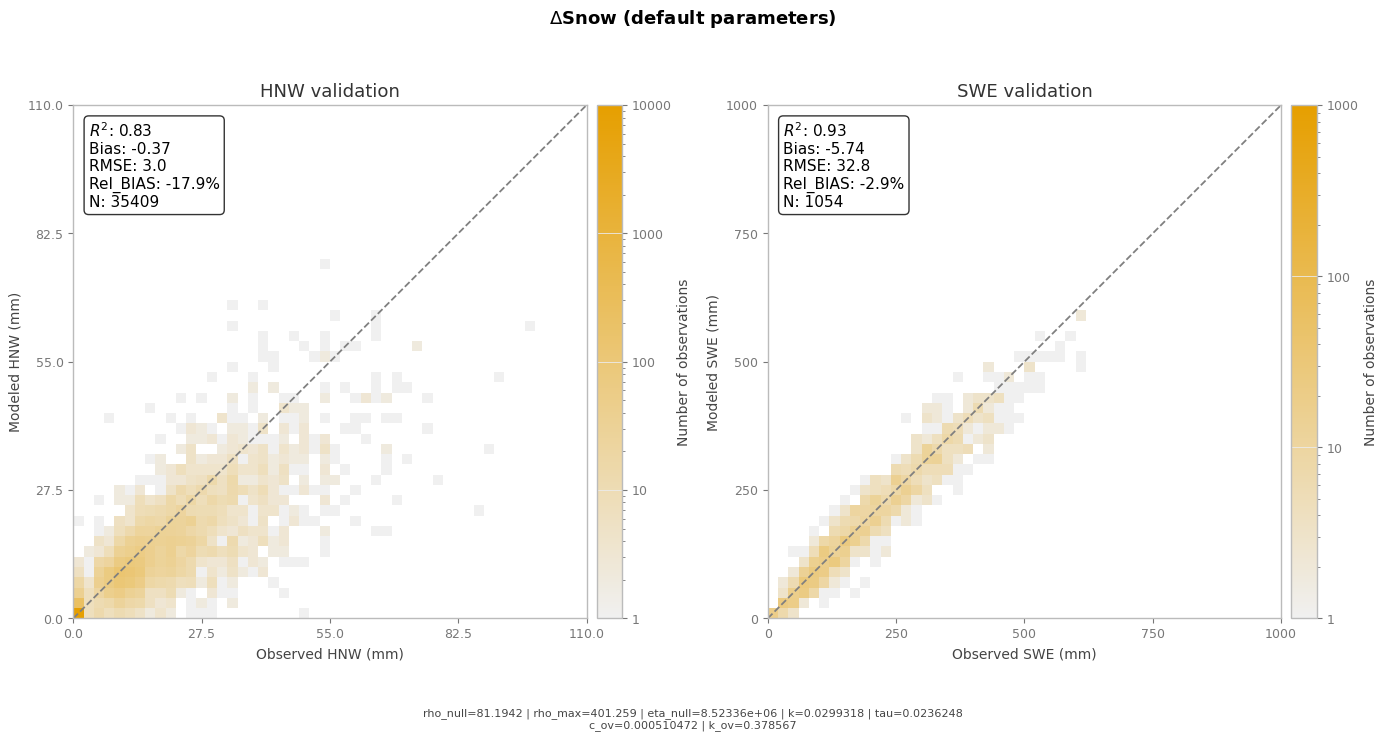

{'HNW': {'RMSE': np.float64(2.970141691081862), 'Bias': np.float64(-0.3669064726101768), 'Rel_BIAS': np.float64(-0.1792713024514109), 'R2': np.float64(0.8277330572291213), 'N': 35409}, 'SWE': {'RMSE': np.float64(32.759450353845736), 'Bias': np.float64(-5.744064118955523), 'Rel_BIAS': np.float64(-0.0289026485933518), 'R2': np.float64(0.9277242790477102), 'N': 1054}}


In [45]:

# ── Derive HNW_mod from day-to-day SWE_mod increments ────────────────────────
# Negative diffs represent melt, not new snow, so clip them to 0.
# .reindex() restores the full time axis (diff drops the first timestep).

HNW_mod = Mag25_data_with_SWE["SWE_mod"].diff(dim="time").clip(min=0)
HNW_mod = HNW_mod.reindex(time=Mag25_data_with_SWE["time"])

Mag25_data_with_SWE["HNW_mod"] = HNW_mod

# ── Build one long-format frame with both pairs (obs & mod) ─────────────────
all_df = (Mag25_data_with_SWE[["HNW", "HNW_mod", "SWE", "SWE_mod", "HS"]]
          .to_dataframe()
          .reset_index()
          .rename(columns={"HNW": "HNW_obs", "SWE": "SWE_obs"}))

# ── Keep only days with a valid observed SWE ────────────────────────────────
# Mag25 SWE is biweekly snow-course data (NaN on most days). Validating on the
# observed days only yields statistically meaningful RMSE / R², and puts the
# HNW and SWE comparisons onto the same subset of rows.

SWE_val = all_df[all_df["SWE_obs"].notna()].copy()


HNW_val = all_df[all_df["HNW_obs"].notna()].copy()
HNW_val.index = pd.to_datetime(HNW_val["time"]).values



print(f"Rows total      : {len(all_df):>7}")
print(f"Rows w/ SWE_obs : {len(SWE_val):>7}")
print(f"Rows w/ HNW_obs : {len(HNW_val):>7}")



# val_helper.validate_swe_mag25(
#     SWE_val,
#     full_season= True,
#     model_name = "dSnow (SnowToSwe)",
#     obs_col    = "SWE_obs",
#     mod_col    = "SWE_mod",
#     save_dir   = save_dir,
#     filename   = f"SnowToSwe_SWE_validation_{calib_comment}.png",
#     cmap       = cmap,
# )

# val_helper.validate_hnw_mag25(
#     HNW_val,
#     full_season = False,
#     model_name = "dSnow (SnowToSwe)",
#     obs_col    = "HNW_obs",
#     mod_col    = "HNW_mod",
#     save_dir   = save_dir,
#     filename   = f"SnowToSwe_hnw_validation_{calib_comment}.png",
#     cmap       = cmap,
# )


results = val_helper.validate_hnw_swe_combined(
    hnw_df     = HNW_val,
    swe_df     = SWE_val,
    model_name = "$\Delta$Snow (default parameters)",
    params     = params_display,
    full_season= False,
    save_dir   = save_dir if save_fig else None,
    filename   = f"dSnow_combined_validation_{calib_comment}.png",
    cmap       = cmap,
)

print(results)

In [42]:
import pandas as pd
import numpy as np

# Load validated optimization summary
csv_path = "/Users/jakobwerkgarner/code/mt_dsnow/calibration/AA_opt_out/Rain_Gauge/res/opt_results_summary_validated.csv"
df = pd.read_csv(csv_path)




keep_cols = [
    c
    for c in [
        "dataset",
        "phase",
        "algorithm",
        "HNW_Rel_BIAS",
        "SWE_RMSE",
        "SWE_Rel_BIAS",
        "rho_null",
        "rho_max",
        "c_ov",
        "k_ov",
        "k",
        "tau",
        "eta_null",

    ]
]

sorted_params = (
    df.assign(HNW_Rel_BIAS_abs=df["SWE_Rel_BIAS"].abs())
      .sort_values("HNW_Rel_BIAS_abs", ascending=True)[keep_cols]
      .reset_index(drop=True)
)

print(f"Rows: {len(sorted_params)}")
sorted_params.head(40)

Rows: 40


,dataset,phase,algorithm,HNW_Rel_BIAS,SWE_RMSE,SWE_Rel_BIAS,rho_null,rho_max,c_ov,k_ov,k,tau,eta_null
0,SNOWPACK,6D,Nelder-Mead,-0.097440,36.077426,0.031905,80.336867,368.675170,0.000576,0.489513,0.021720,0.023845,8.244306e+06
1,SNOWPACK,2A,DE,-0.210294,34.718610,0.044369,53.364399,408.028855,0.000082,0.754820,0.026671,0.010606,2.447481e+06
2,SNOWPACK,2C,DE,-0.171348,35.714381,0.046606,60.820703,391.711465,0.000832,0.860503,0.025525,0.010212,3.531213e+06
3,SNOWPACK,1A,Nelder-Mead,-0.164297,36.658609,0.051781,68.575754,406.402750,0.000558,0.361264,0.020654,0.024378,9.790841e+06
4,SNOWPACK,1B,Nelder-Mead,-0.091080,37.079356,0.052536,80.917342,381.213367,0.000593,0.418132,0.021732,0.022310,8.834301e+06
5,SNOWPACK,3C,DE,-0.185622,35.823596,0.052665,58.434309,402.384925,0.000266,0.672542,0.025296,0.010902,3.250824e+06
6,SNOWPACK,5C,Nelder-Mead,0.053940,37.559575,0.053123,110.024003,367.759333,0.000564,0.444627,0.027096,0.025775,7.793845e+06
7,SNOWPACK,2B,DE,-0.185230,35.821447,0.053343,58.113439,404.664093,0.000680,0.873578,0.028185,0.012921,2.383090e+06
8,SNOWPACK,2C,Nelder-Mead,-0.004737,36.364605,0.054082,101.166403,380.012334,0.000578,0.411667,0.026926,0.022685,8.232495e+06
9,SNOWPACK,4C,Nelder-Mead,0.025503,36.992831,0.054977,106.197284,374.069708,0.000566,0.399957,0.026927,0.022194,8.733750e+06


In [43]:
# Choose the row index from `sorted_params`
chosen_index = 0  # <- change this

row = sorted_params.iloc[chosen_index]

print(f"Selected row index: {chosen_index}")
print(f"calib_coment = '{row['dataset']}_{row['phase']}_{row['algorithm']}'")

print(
    "snow_to_swe = SnowToSwe(\n"
    f"     rho_max={row['rho_max']},\n"
    f"     rho_null={row['rho_null']},\n"
    f"     eta_null={row['eta_null']},\n"
    f"     k={row['k']},\n"
    f"     tau={row['tau']},\n"
    f"     c_ov={row['c_ov']},\n"
    f"     k_ov={row['k_ov']},\n"
    ")"
)

Selected row index: 0
calib_coment = 'SNOWPACK_6D_Nelder-Mead'
snow_to_swe = SnowToSwe(
     rho_max=368.675169526059,
     rho_null=80.3368668356733,
     eta_null=8244305.90802216,
     k=0.0217198147482688,
     tau=0.0238447069185229,
     c_ov=0.0005764484579278,
     k_ov=0.489512653286261,
)
